# Caso de Estudio 4: Aprendizaje por Refuerzo
Este notebook simula un examen de **Aprendizaje por Refuerzo (Reinforcement Learning)** que evalúa:
1. Simulación de un entorno Gridworld de navegación logística.
2. Algoritmo Q-Learning con la **Ecuación de Bellman**.
3. **Búsqueda por Grilla de Hiperparámetros** de Q-Learning ($lpha$, $\gamma$) para evaluar convergencia.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Entorno Gridworld simplificado (4x4)
class LogisticsEnv:
    def __init__(self):
        self.grid_size = 4
        self.state = (0, 0)
        self.goal = (3, 3)
        self.trap = (2, 2)
        
    def reset(self):
        self.state = (0, 0)
        return 0
        
    def step(self, action):
        r, c = self.state
        if action == 0:   r = max(0, r - 1)
        elif action == 1: r = min(self.grid_size - 1, r + 1)
        elif action == 2: c = max(0, c - 1)
        elif action == 3: c = min(self.grid_size - 1, c + 1)
        
        self.state = (r, c)
        state_idx = r * self.grid_size + c
        
        if self.state == self.goal:
            return state_idx, 20, True
        elif self.state == self.trap:
            return state_idx, -20, True
        else:
            return state_idx, -1, False


## 1. Optimización por Grilla de Hiperparámetros de Q-Learning


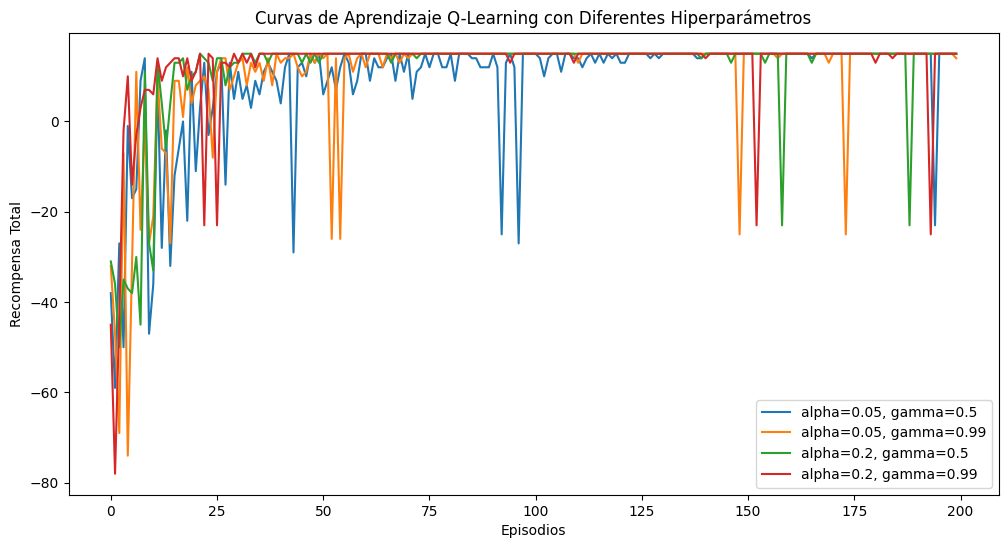

In [2]:
# Definimos combinaciones de hiperparámetros a evaluar
alphas = [0.05, 0.2]
gammas = [0.5, 0.99]
num_episodes = 200
env = LogisticsEnv()

plt.figure(figsize=(12, 6))

for alpha in alphas:
    for gamma in gammas:
        # Inicializar Q-Table
        Q = np.zeros((16, 4))
        epsilon = 0.5
        recompensas = []
        
        for ep in range(num_episodes):
            s = env.reset()
            done = False
            total_r = 0
            
            while not done:
                # Epsilon-Greedy
                if np.random.rand() < epsilon:
                    a = np.random.choice(4)
                else:
                    a = np.argmax(Q[s])
                    
                s_next, r, done = env.step(a)
                
                # Bellman
                Q[s, a] = Q[s, a] + alpha * (r + gamma * np.max(Q[s_next]) - Q[s, a])
                s = s_next
                total_r += r
                
            epsilon = max(0.01, epsilon * 0.95)
            recompensas.append(total_r)
            
        plt.plot(recompensas, label=f'alpha={alpha}, gamma={gamma}')

plt.title('Curvas de Aprendizaje Q-Learning con Diferentes Hiperparámetros')
plt.xlabel('Episodios')
plt.ylabel('Recompensa Total')
plt.legend()
plt.show()


## 2. Banco de Preguntas Teóricas (Nivel Examen)
*   **Pregunta 1:** ¿Qué combinación de hiperparámetros converge más rápido en el gráfico y cómo lo explica teóricamente?
    *   *Respuesta:* Típicamente `alpha=0.2, gamma=0.99` converge más rápido. Un `alpha` de 0.2 permite que el agente actualice con mayor velocidad los valores Q tras recibir recompensas de éxito, mientras que un `gamma` alto de 0.99 le da una visión a largo plazo necesaria para valorar las celdas intermedias del camino óptimo.
*   **Pregunta 2:** ¿Por qué se utiliza el decaimiento de Epsilon a lo largo de los episodios?
    *   *Respuesta:* Al inicio (epsilon alto), el agente desconoce el entorno y necesita **explorar** aleatoriamente. A medida que pasan los episodios y la Q-table tiene valores bien calibrados, el agente debe reducir epsilon para dejar de hacer movimientos aleatorios y empezar a **explotar** el camino óptimo aprendido, logrando estabilidad.
